Load the data frame

In [253]:
import pandas as pd
df = pd.read_csv("customer_churn.csv")

Importing libraries

In [254]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, RobustScaler

In [255]:
df_fe = df.copy()

In [256]:
df_fe

,Customer_ID,Age,Income,Gender,Education,Region,Signup_Date,Churned
0,1,35,28000.0,Male,High School,West,2023-03-16,1
1,2,59,21000.0,Male,Bachelor,West,2023-01-08,0
2,3,56,30000.0,Male,PhD,West,2023-02-14,1
3,4,34,47000.0,Female,Master,North,2023-02-28,1
4,5,31,20000.0,Male,High School,North,2023-05-12,1
...,...,...,...,...,...,...,...,...
795,796,33,37000.0,Female,High School,North,2023-04-30,0
796,797,64,22000.0,Male,High School,East,2023-02-15,1
797,798,32,31000.0,Female,PhD,West,2023-05-14,1
798,799,42,22000.0,Male,PhD,East,2023-02-25,1


Data type transformations

In [257]:
df.dtypes

Customer_ID      int64
Age              int64
Income         float64
Gender          object
Education       object
Region          object
Signup_Date     object
Churned          int64
dtype: object

In [258]:
# Age as an integer
df_fe['Age'] = df_fe['Age'].astype(int)

# Income as a float
df_fe['Income'] = df_fe['Income'].astype(float) 

# Gender, education, region and churned as categories
df_fe['Gender'] = df_fe['Gender'].astype('category')
df_fe['Education'] = df_fe['Education'].astype('category')
df_fe['Region'] = df_fe['Region'].astype('category')
df_fe['Churned'] = df_fe['Churned'].astype('category')

# Sign up date as a date time
df_fe['Signup_Date'] = pd.to_datetime(df_fe['Signup_Date'], format = "%Y-%m-%d", errors="coerce")

In [259]:
df_fe.dtypes

Customer_ID             int64
Age                     int64
Income                float64
Gender               category
Education            category
Region               category
Signup_Date    datetime64[ns]
Churned              category
dtype: object

### Numerical Feature Engineering

In [260]:
import numpy as np

# 1. Mathematical Transformation

# log() to reduce skewness in Income
df_fe['Log_Income'] = np.log(df_fe['Income'])

# sqrt() to stabilize variance
df['sqrt_age'] = np.sqrt(df['Age'])

In [ ]:
# 2. Binning / Discretization
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=[0,25,50,100], labels=['Young','Adult','Senior'])

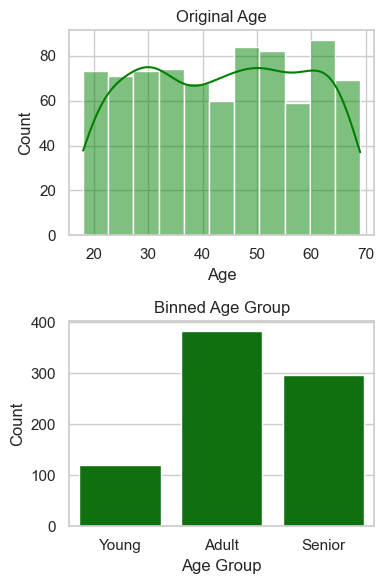

In [275]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(4, 6))

# 1. Original Age
sns.histplot(df_fe['Age'], kde=True, color='green', ax=axes[0])
axes[0].set_title('Original Age', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# 2. Binned Age_Group
sns.countplot(x='Age_Group', data=df_fe, color='green', ax=axes[1])
axes[1].set_title('Binned Age Group', fontsize=12)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [262]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, RobustScaler

# 3. Normalization / Scaling: scale Age to range [0,1]
scaler = MinMaxScaler()
df_fe['Age_Scaled'] = scaler.fit_transform(df_fe[['Age']])

# 4. Standardization: scale log(Income) to mean=0, std=1
std_scaler = StandardScaler()
df_fe['Log_Income_Std'] = std_scaler.fit_transform(df_fe[['Log_Income']])

# 5. RobustScaler: scale  income using median and IQR
robust_scaler = RobustScaler()
df_fe['Income_Robust'] = robust_scaler.fit_transform(df_fe[['Income']])

In [263]:
df_fe[['Income', 'Log_Income', 'Log_Income_Std', 'Income_Robust']].head()

,Income,Log_Income,Log_Income_Std,Income_Robust
0,28000.0,10.239960,0.496154,0.421053
1,21000.0,9.952278,-0.089007,-0.070175
2,30000.0,10.308953,0.636490,0.561404
3,47000.0,10.757903,1.549679,1.754386
4,20000.0,9.903488,-0.188249,-0.140351


Visualization

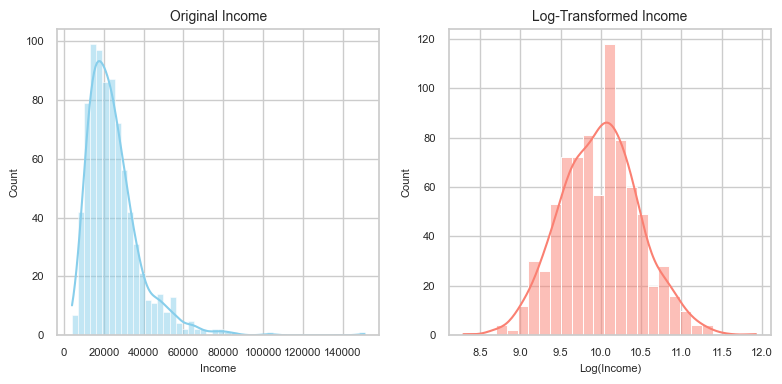

In [264]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Income --> Log_Income
sns.histplot(df_fe['Income'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Original Income', fontsize=10)
axes[0].set_xlabel('Income', fontsize=8)
axes[0].set_ylabel('Count', fontsize=8)
axes[0].tick_params(axis='both', labelsize=8)

sns.histplot(df_fe['Log_Income'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Log-Transformed Income', fontsize=10)
axes[1].set_xlabel('Log(Income)', fontsize=8)
axes[1].set_ylabel('Count', fontsize=8)
axes[1].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

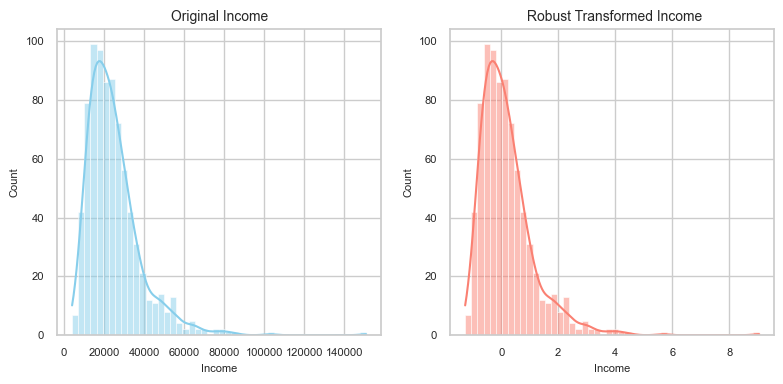

In [265]:

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Income --> Log_Income
sns.histplot(df_fe['Income'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Original Income', fontsize=10)
axes[0].set_xlabel('Income', fontsize=8)
axes[0].set_ylabel('Count', fontsize=8)
axes[0].tick_params(axis='both', labelsize=8)

sns.histplot(df_fe['Income_Robust'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title(' Robust Transformed Income', fontsize=10)
axes[1].set_xlabel('Income', fontsize=8)
axes[1].set_ylabel('Count', fontsize=8)
axes[1].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()


### Categorical Feature Engineering

In [ ]:
# 1. Label Encoding: convert Gender categories into integers
le = LabelEncoder()
df_fe['Gender_Label'] = le.fit_transform(df_fe['Gender'])

# 2. Ordinal Encoding: encode Education with meaningful order
education_order = {'High School':0, 'Bachelor':1, 'Master':2, 'PhD':3}
df_fe['Education_Ord'] = df_fe['Education'].map(education_order)

# 3. One-Hot Encoding: create binary columns for each Region
df_fe = pd.get_dummies(df_fe, columns=['Region'], prefix='Region')

# 4. Dummy Encoding: create binary columns with one less than total
df_fe_dummy = pd.get_dummies(df, columns=['Region'], prefix='Region', drop_first=True)

# 5. Target Encoding: replace Region with average churn rate
target_mean = df.groupby('Region')['Churned'].mean().to_dict()
df_fe['Region_TargetEnc'] = df['Region'].map(target_mean)

### Date-Time Feature Engineering

In [267]:
# 1. Extract year component
df_fe['Signup_Year'] = df_fe['Signup_Date'].dt.year  

# 2. Extract month component
df_fe['Signup_Month'] = df_fe['Signup_Date'].dt.month  

# 3. Extract day component
df_fe['Signup_Day'] = df_fe['Signup_Date'].dt.day  

# 4. Extract weekday component
df_fe['Signup_Weekday'] = df_fe['Signup_Date'].dt.weekday  
df_fe['Weekday_Name'] = df_fe['Signup_Date'].dt.day_name()  # for reference

# 5. Boolean feature: whether signup was on weekend
df_fe['Is_Weekend'] = df_fe['Signup_Date'].dt.weekday >=5 

# 6. Time difference feature: days since signup
df_fe['Days_Since_Signup'] = (pd.to_datetime('2023-06-01') - df_fe['Signup_Date']).dt.days  

In [268]:
df_fe.head()

,Customer_ID,Age,Income,Gender,Education,Signup_Date,Churned,Log_Income,Age_Group,Age_Scaled,...,Region_West,Region_TargetEnc,Gender_Male,Signup_Year,Signup_Month,Signup_Day,Signup_Weekday,Weekday_Name,Is_Weekend,Days_Since_Signup
0,1,35,28000.0,Male,High School,2023-03-16,1,10.239960,Adult,0.333333,...,True,0.383838,1,2023,3,16,3,Thursday,False,77
1,2,59,21000.0,Male,Bachelor,2023-01-08,0,9.952278,Senior,0.803922,...,True,0.383838,1,2023,1,8,6,Sunday,True,144
2,3,56,30000.0,Male,PhD,2023-02-14,1,10.308953,Senior,0.745098,...,True,0.383838,1,2023,2,14,1,Tuesday,False,107
3,4,34,47000.0,Female,Master,2023-02-28,1,10.757903,Adult,0.313725,...,False,0.410377,0,2023,2,28,1,Tuesday,False,93
4,5,31,20000.0,Male,High School,2023-05-12,1,9.903488,Adult,0.254902,...,False,0.410377,1,2023,5,12,4,Friday,False,20
